In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import cleaning as cln 

warnings.filterwarnings("ignore")

### CẤU HÌNH HIỂN THỊ TOÀN CỤC

In [69]:
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA",
    "axes.facecolor":   "#F0F0F5",
    "figure.dpi":       130,
})
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

RAW_PATH    = "cellphones_raw.csv"
ANTUTU_PATH = "antutu_socket.csv"

### CHƯƠNG 1: TÌM HIỂU DỮ LIỆU & CHIẾN THUẬT PROXY

1.1 Đọc dữ liệu 

In [70]:

df_raw    = pd.read_csv(RAW_PATH)
df_antutu = pd.read_csv(ANTUTU_PATH)

print(f"\n[raw]    Shape : {df_raw.shape}  →  {df_raw.shape[0]} sản phẩm, {df_raw.shape[1]} thuộc tính")
print(f"[antutu] Shape : {df_antutu.shape}  →  {df_antutu.shape[0]} chipsets\n")

print("─── df_raw.info() ───")
df_raw.info(verbose=True, show_counts=True)




[raw]    Shape : (966, 50)  →  966 sản phẩm, 50 thuộc tính
[antutu] Shape : (233, 6)  →  233 chipsets

─── df_raw.info() ───
<class 'pandas.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Unnamed                 966 non-null    int64
 1    0                      966 non-null    int64
 2   Name                    966 non-null    str  
 3   Price                   333 non-null    str  
 4   Link                    966 non-null    str  
 5   Kích thước màn hình     873 non-null    str  
 6   Công nghệ màn hình      814 non-null    str  
 7   Camera sau              855 non-null    str  
 8   Camera trước            823 non-null    str  
 9   Chipset                 857 non-null    str  
 10  Công nghệ NFC           762 non-null    str  
 11  Bộ nhớ trong            915 non-null    str  
 12  Thẻ SIM                 696 non-null    str  
 13  Hệ điều hà

 1.2 Phân tích Missing Values 

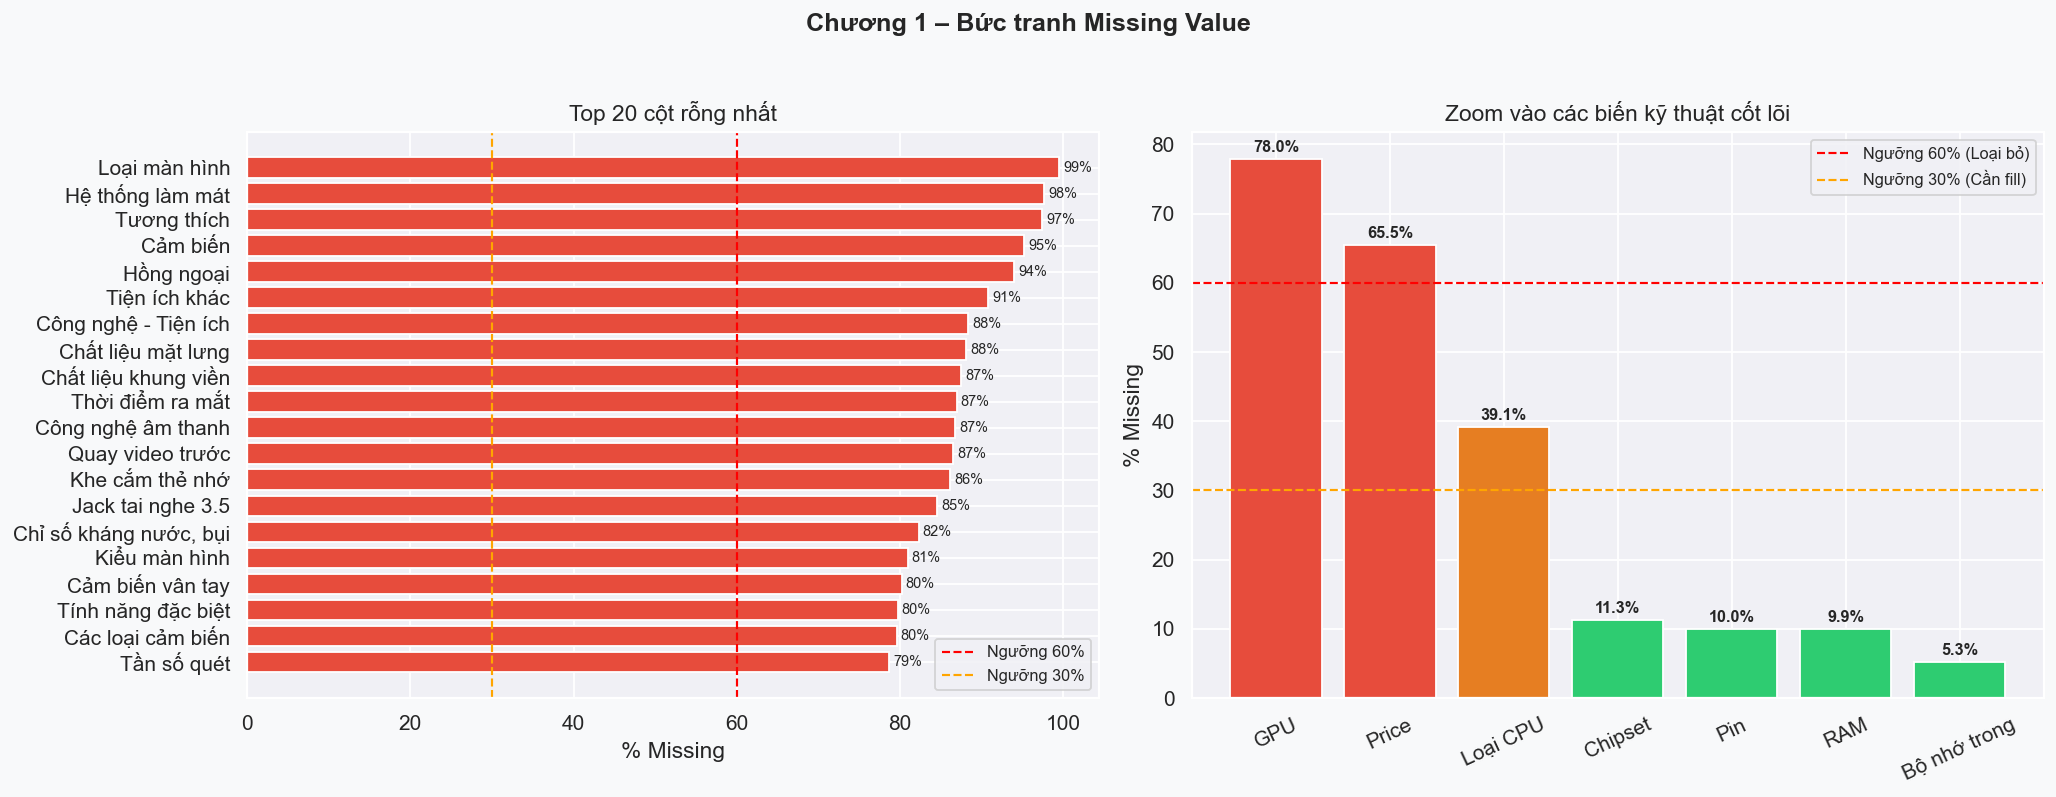

In [71]:

null_summary = (
    df_raw.isna().sum()
    .rename("null_count")
    .to_frame()
    .assign(null_pct=lambda x: x["null_count"] / len(df_raw) * 100)
    .sort_values("null_pct", ascending=False)
)

def plot_missing_values(df_raw, null_summary):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Chương 1 – Bức tranh Missing Value",
                 fontsize=14, fontweight="bold", y=1.02)

    # Subplot trái: Top 20 cột rỗng nhất
    top20 = null_summary.head(20)
    colors = ["#E74C3C" if p > 60 else "#E67E22" if p > 30 else "#3498DB" for p in top20["null_pct"]]
    axes[0].barh(top20.index[::-1], top20["null_pct"][::-1], color=colors[::-1])
    axes[0].axvline(60, color="red",    linestyle="--", linewidth=1.2, label="Ngưỡng 60%")
    axes[0].axvline(30, color="orange", linestyle="--", linewidth=1.2, label="Ngưỡng 30%")
    axes[0].set_xlabel("% Missing")
    axes[0].set_title("Top 20 cột rỗng nhất")
    axes[0].legend(fontsize=9)
    for i, val in enumerate(top20["null_pct"][::-1]):
        axes[0].text(val + 0.5, i, f"{val:.0f}%", va="center", fontsize=8)

    # Subplot phải: Biến kỹ thuật cốt lõi
    key_cols = {
        "Price":       df_raw["Price"].isna().mean() * 100,
        "GPU":         df_raw["GPU"].isna().mean() * 100,
        "Loại CPU":    df_raw["Loại CPU"].isna().mean() * 100,
        "Chipset":     df_raw["Chipset"].isna().mean() * 100,
        "RAM":         df_raw["Dung lượng RAM"].isna().mean() * 100,
        "Pin":         df_raw["Pin"].isna().mean() * 100,
        "Bộ nhớ trong":df_raw["Bộ nhớ trong"].isna().mean() * 100,
    }
    key_df  = pd.Series(key_cols).sort_values(ascending=False)
    bar_col = ["#E74C3C" if v > 60 else "#E67E22" if v > 30 else "#2ECC71" for v in key_df]
    bars = axes[1].bar(key_df.index, key_df.values, color=bar_col, edgecolor="white")
    axes[1].axhline(60, color="red",    linestyle="--", linewidth=1.2, label="Ngưỡng 60% (Loại bỏ)")
    axes[1].axhline(30, color="orange", linestyle="--", linewidth=1.2, label="Ngưỡng 30% (Cần fill)")
    axes[1].set_ylabel("% Missing")
    axes[1].set_title("Zoom vào các biến kỹ thuật cốt lõi")
    axes[1].legend(fontsize=9)
    axes[1].tick_params(axis="x", rotation=25)
    for bar, val in zip(bars, key_df.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_missing_values(df_raw, null_summary)

1.3 Thực Hiện Merge Dựa Trên Thư Viện Chuẩn 


[Merge Result thực tế từ cln.add_chipset_info]
  Số dòng sau merge    : 966
  Match Antutu         : 748/966 (77.4%)
  GPU_final coverage   : 77.4%  (từ 22.0% lên 77.4%)


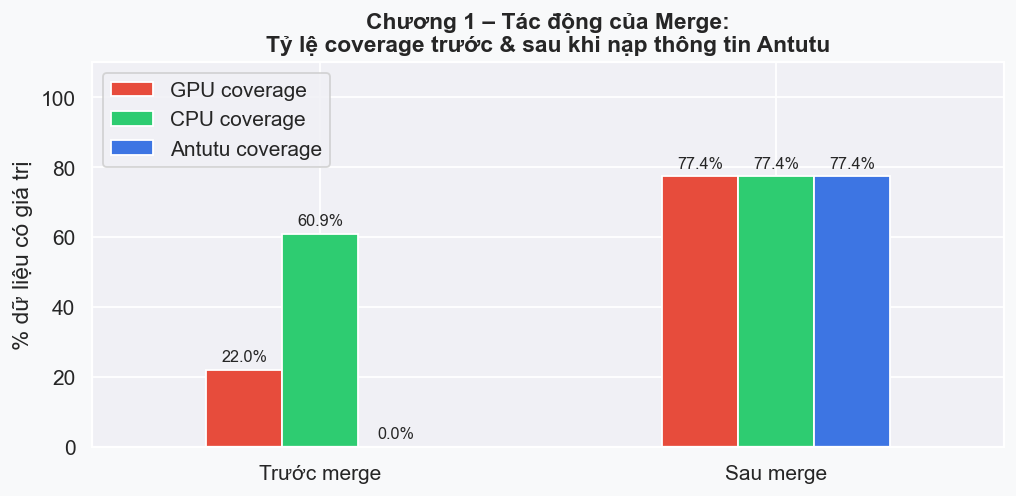


↳ KẾT LUẬN CHƯƠNG 1: Vì vậy, logic xử lý này sẽ được đóng gói thành hàm add_chipset_info trong file Preprocessing.


In [72]:

df_merged = cln.add_chipset_info(df_antutu, df_raw)

# Tính toán các chỉ số bao phủ (coverage) sau khi chạy hàm thực tế
gpu_fill_rate = df_merged["gpu"].notna().mean() * 100
match_rate    = df_merged["antutu_11"].notna().mean() * 100
arch_coverage = df_merged["architecture"].notna().mean() * 100

print(f"\n[Merge Result thực tế từ cln.add_chipset_info]")
print(f"  Số dòng sau merge    : {len(df_merged):,}")
print(f"  Match Antutu         : {df_merged['antutu_11'].notna().sum()}/{len(df_merged)} ({match_rate:.1f}%)")
print(f"  GPU_final coverage   : {gpu_fill_rate:.1f}%  (từ {(df_raw['GPU'].notna().mean()*100):.1f}% lên {gpu_fill_rate:.1f}%)")

def plot_merge_impact(df_raw, df_merged, gpu_fill_rate, arch_coverage, match_rate):
    compare_df = pd.DataFrame({
        "Trước merge": {
            "GPU coverage": df_raw["GPU"].notna().mean() * 100,
            "CPU coverage": (100 - 39.1),
            "Antutu coverage": 0.0,
        },
        "Sau merge": {
            "GPU coverage": gpu_fill_rate,
            "CPU coverage": arch_coverage,
            "Antutu coverage": match_rate,
        }
    })
    fig, ax = plt.subplots(figsize=(8, 4))
    compare_df.T.plot(kind="bar", ax=ax, color=["#E74C3C", "#2ECC71", "#3d75e3"], edgecolor="white", width=0.5)
    ax.set_title("Chương 1 – Tác động của Merge:\nTỷ lệ coverage trước & sau khi nạp thông tin Antutu", fontweight="bold")
    ax.set_ylabel("% dữ liệu có giá trị")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

plot_merge_impact(df_raw, df_merged, gpu_fill_rate, arch_coverage, match_rate)

print("\n↳ KẾT LUẬN CHƯƠNG 1: Vì vậy, logic xử lý này sẽ được đóng gói thành hàm add_chipset_info trong file Preprocessing.")

### CHƯƠNG 2: KHÁM PHÁ CẤU TRÚC DỮ LIỆU

Minh họa dữ liệu text thô

In [73]:
# ──  ──────────────────────────────────────────
print("\n─── Ví dụ tên sản phẩm thô (chứa RAM/ROM trong Name) ───")
sample_names = df_raw["Name"].dropna().head(12).tolist()
for i, name in enumerate(sample_names, 1):
    print(f"  [{i:02d}] {name}")


─── Ví dụ tên sản phẩm thô (chứa RAM/ROM trong Name) ───
  [01] iPhone 17 Pro 256GB | Chính hãng
  [02] OPPO Find X9s 12GB 256GB
  [03] Samsung Galaxy S26 Ultra 12GB 256GB
  [04] iPhone 17 Pro Max 256GB | Chính hãng
  [05] Samsung Galaxy S26 12GB 256GB
  [06] iPhone 17 256GB | Chính hãng
  [07] Samsung Galaxy S25 Ultra 12GB 256GB
  [08] Điện thoại Itel P55 Plus NFC 8GB 256GB
  [09] Samsung Galaxy A17 5G 8GB 128GB
  [10] iPhone Air 256GB | Chính hãng
  [11] iPhone 15 128GB | Chính hãng VN/A
  [12] Điện thoại iPhone 16 Pro Max 256GB


2.1 Áp dụng hàm Trích Xuất Thực Tế từ module `cln`

In [74]:
df_merged["RAM_GB"]  = df_merged["Dung lượng RAM"].apply(cln.clean_metrics)
df_merged["ROM_GB"]  = df_merged["Bộ nhớ trong"].apply(cln.clean_metrics)
df_merged["Bat_mAh"] = df_merged["Pin"].apply(cln.clean_metrics)
df_merged["Brand"]   = df_merged["Name"].apply(cln.get_brand)
df_merged["Refresh Rate"] = df_merged.apply(lambda row: cln.extract_refresh_rate(row['Tần số quét'], row['Tính năng màn hình']),
    axis=1)

print("\n─── Kiểm tra kết quả trích xuất bằng hàm cln (10 dòng đầu) ───")
check_cols = ["Name", "RAM_GB", "ROM_GB", "Bat_mAh", "Brand", "antutu_11", "Refresh Rate"]
print(df_merged[check_cols].head(10).to_string(index=False))


─── Kiểm tra kết quả trích xuất bằng hàm cln (10 dòng đầu) ───
                                  Name  RAM_GB  ROM_GB  Bat_mAh   Brand  antutu_11  Refresh Rate
      iPhone 17 Pro 256GB | Chính hãng     NaN   256.0      NaN  iPhone  2606807.0         120.0
              OPPO Find X9s 12GB 256GB    12.0   256.0   7025.0    OPPO  3041307.0         120.0
   Samsung Galaxy S26 Ultra 12GB 256GB    12.0   256.0   5000.0 Samsung  3932243.0         120.0
  iPhone 17 Pro Max 256GB | Chính hãng     NaN   256.0      NaN  iPhone  2606807.0         120.0
         Samsung Galaxy S26 12GB 256GB    12.0   256.0   4300.0 Samsung  3145925.0         120.0
          iPhone 17 256GB | Chính hãng     NaN   256.0     30.0  iPhone  2239708.0         120.0
   Samsung Galaxy S25 Ultra 12GB 256GB    12.0   256.0   5000.0 Samsung  3336910.0         120.0
Điện thoại Itel P55 Plus NFC 8GB 256GB     8.0   256.0   5000.0    Điện   330006.0          90.0
       Samsung Galaxy A17 5G 8GB 128GB     8.0   128.0   5000.0

In [75]:
df_merged[check_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          966 non-null    str    
 1   RAM_GB        870 non-null    float64
 2   ROM_GB        915 non-null    float64
 3   Bat_mAh       866 non-null    float64
 4   Brand         966 non-null    str    
 5   antutu_11     748 non-null    float64
 6   Refresh Rate  633 non-null    float64
dtypes: float64(5), str(2)
memory usage: 53.0 KB


In [76]:
print("\nFill thêm hai cột RAM_GB, Bat_mAh, Refresh_Rate")


Fill thêm hai cột RAM_GB, Bat_mAh, Refresh_Rate


2.2 Phát hiện "Dopplegangers" bằng hàm chuẩn hóa thực tế

In [77]:
df_merged["Name_clean"] = df_merged["Name"].apply(cln.clean_phone_name)

dup_names = df_merged[df_merged.duplicated("Name_clean", keep=False)].sort_values("Name_clean")
print(f"\n  Số dòng có tên trùng (sau khi clean_phone_name): {len(dup_names)} / {len(df_merged)}")

sample_dup_name = (
    dup_names.groupby("Name_clean")
    .filter(lambda x: (x["RAM_GB"].nunique() > 1) | (x["ROM_GB"].nunique() > 1))
    .groupby("Name_clean").head(3).head(9)
)
print("\n─── Ví dụ: Cùng tên sau clean, khác cấu hình RAM/ROM thực tế ───")
if not sample_dup_name.empty:
    print(sample_dup_name[["Name_clean", "RAM_GB", "ROM_GB", "antutu_11"]].to_string(index=False))
else:
    print(dup_names[["Name_clean", "RAM_GB", "ROM_GB"]].head(9).to_string(index=False))


  Số dòng có tên trùng (sau khi clean_phone_name): 375 / 966

─── Ví dụ: Cùng tên sau clean, khác cấu hình RAM/ROM thực tế ───
    Name_clean  RAM_GB  ROM_GB  antutu_11
     honor 400    12.0   256.0  1020938.0
     honor 400    12.0   512.0  1020938.0
honor 600 lite     8.0   256.0        NaN
honor 600 lite     8.0   256.0        NaN
honor 600 lite    12.0   256.0        NaN
      honor 90    12.0   256.0   829085.0
      honor 90     8.0   256.0   829085.0
    honor x50i     8.0   128.0   527185.0
    honor x50i     6.0   128.0   419670.0


Vấn đề này sẽ được xử lý bằng cách gộp các dòng có cùng tên lại làm một và tạo thêm 4 biến mới thay cho 2 biến RAM và ROM

2.3 Đồ họa hóa Phân phối Thị trường & RAM/ROM

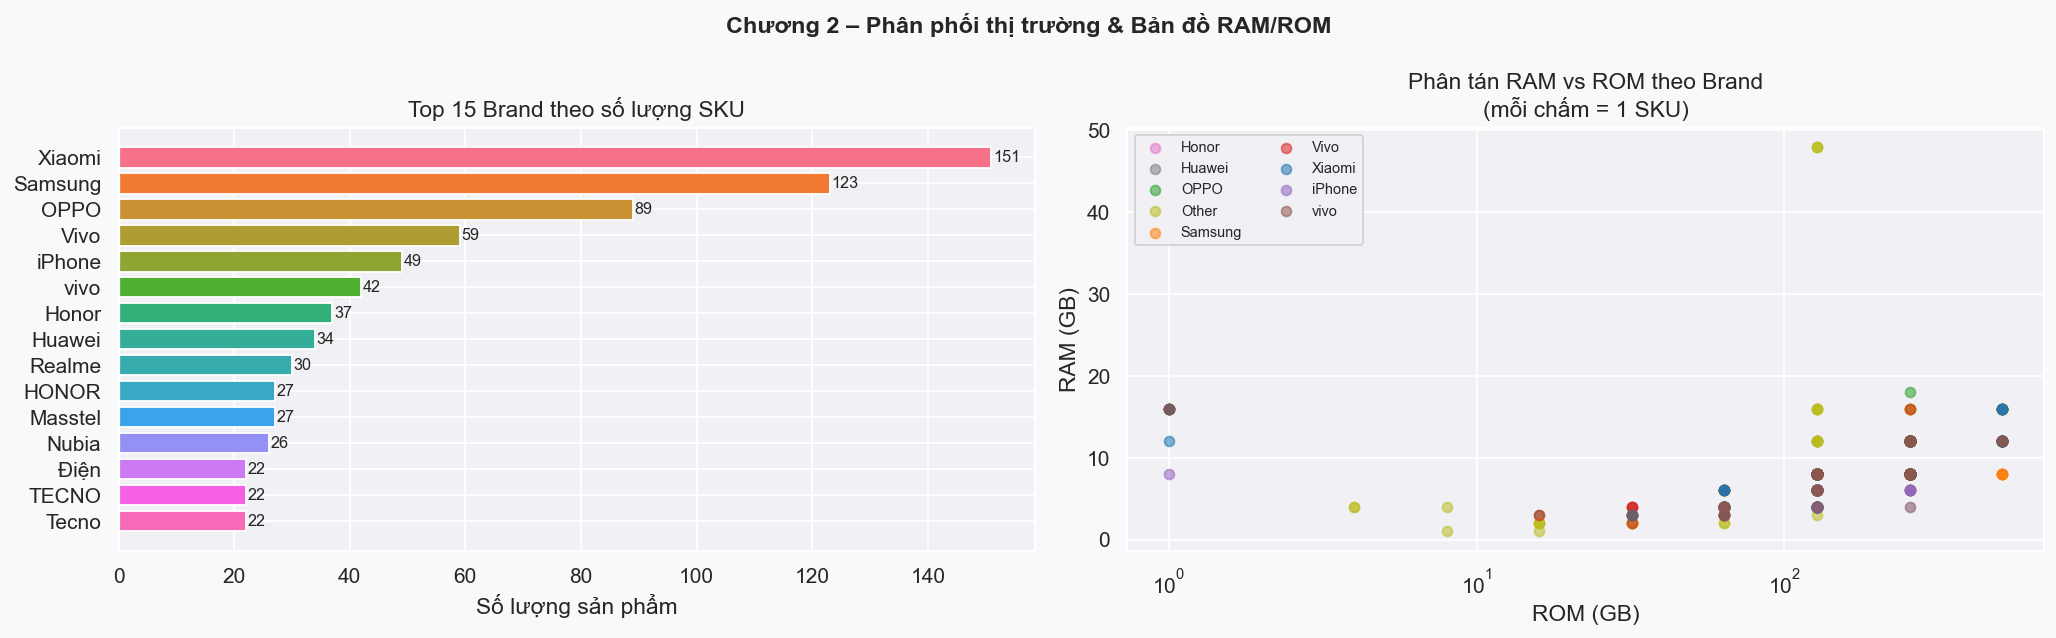


↳ KẾT LUẬN CHƯƠNG 2: Vì vậy, logic xử lý này sẽ được đóng gói thành hàm clean_metrics, clean_phone_name và get_brand trong file Preprocessing.


In [78]:
brand_counts = df_merged["Brand"].value_counts().head(15)

def plot_brand_distribution(df_merged, brand_counts):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Chương 2 – Phân phối thị trường & Bản đồ RAM/ROM", fontsize=13, fontweight="bold")

    # Barh: Top 15 Brands
    palette_brands = sns.color_palette("husl", len(brand_counts))
    axes[0].barh(brand_counts.index[::-1], brand_counts.values[::-1], color=palette_brands[::-1])
    axes[0].set_xlabel("Số lượng sản phẩm")
    axes[0].set_title("Top 15 Brand theo số lượng SKU")
    for i, val in enumerate(brand_counts.values[::-1]):
        axes[0].text(val + 0.3, i, str(val), va="center", fontsize=9)

    # Scatter: RAM vs ROM
    scatter_data = df_merged[df_merged["RAM_GB"].notna() & df_merged["ROM_GB"].notna()].copy()
    top_brands_list = brand_counts.head(8).index.tolist()
    scatter_data["Brand_label"] = scatter_data["Brand"].apply(lambda b: b if b in top_brands_list else "Other")
    palette_scatter = dict(zip(top_brands_list + ["Other"], sns.color_palette("tab10", len(top_brands_list) + 1)))
    
    for brand_lbl, grp in scatter_data.groupby("Brand_label"):
        axes[1].scatter(grp["ROM_GB"], grp["RAM_GB"], label=brand_lbl, alpha=0.55, s=30, color=palette_scatter.get(brand_lbl, "gray"))
    axes[1].set_xlabel("ROM (GB)")
    axes[1].set_ylabel("RAM (GB)")
    axes[1].set_title("Phân tán RAM vs ROM theo Brand\n(mỗi chấm = 1 SKU)")
    axes[1].legend(fontsize=8, ncol=2)
    axes[1].set_xscale("log")
    plt.tight_layout()
    plt.show()

plot_brand_distribution(df_merged, brand_counts)

print("\n↳ KẾT LUẬN CHƯƠNG 2: Vì vậy, logic xử lý này sẽ được đóng gói thành hàm clean_metrics, clean_phone_name và get_brand trong file Preprocessing.")

2.4 Những sản phẩm không phải điện thoại

In [79]:
df_merged['Kích thước màn hình'] = df_merged['Kích thước màn hình'].apply(cln.clean_metrics)

mask_not_smartphone = (
    (df_merged['Kích thước màn hình'] < 4.0) |
    (df_merged['Name_clean'].str.lower().str.contains('tab|pad|win rt', na=False))
)

df_merged = df_merged[~mask_not_smartphone].reset_index(drop=True)
print(f'Có {mask_not_smartphone.sum()} sản phẩm không phải điện thoại, còn lại {len(df_merged)}')

Có 42 sản phẩm không phải điện thoại, còn lại 924
